Loan Repayment Prediction 

Predicts whether the bank should approves the loan of an applicant based on his profit

## Importing the libraries

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import StratifiedKFold
kFold = StratifiedKFold(n_splits=5)
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from  sklearn.metrics  import  accuracy_score , precision_score , recall_score,confusion_matrix,classification_report
   

## Reading file

In [104]:
data=pd.read_csv('loan_approval_dataset.csv')

In [105]:
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## Exploratory Data Analysis (EDA)

### Understand the Dataset

In [106]:
#Consise summary :to explore columns types:Shape, datatypes, and not null-counts 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


we have 2 columns dtype objct we need to handle them

In [107]:
data.shape

(4269, 13)

In [108]:
# data summary :Summary Statistics for numeric columns
data.describe()


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [109]:
#columns
data.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

### Target Variable Distribution

In [110]:
# Target Variable Distribution
data[' loan_status'].value_counts()

 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

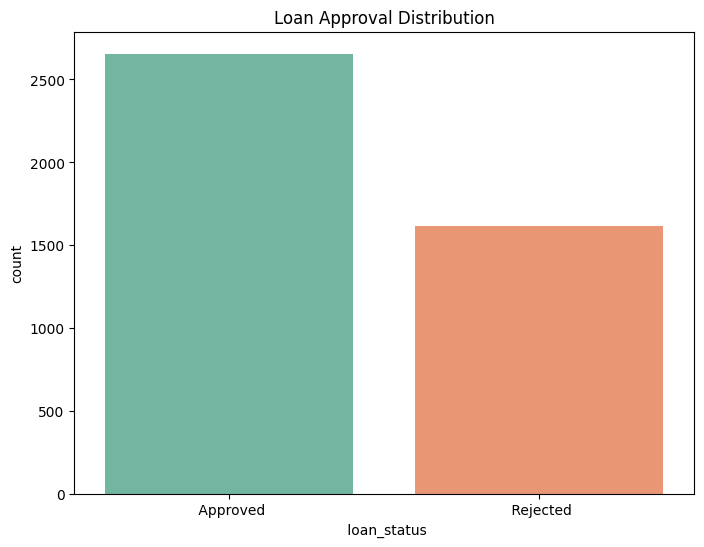

In [111]:
#Visualize Data: Target Distribution
plt.figure(figsize=(8,6))
sns.countplot(data=data, x=' loan_status', palette='Set2')
plt.title('Loan Approval Distribution')
plt.show()

### Categorical Features Analysis

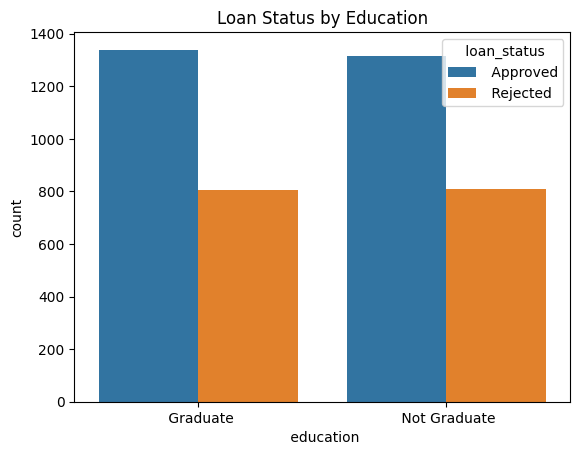

In [112]:
# Education vs Loan-Status
sns.countplot(data=data, x=' education', hue=' loan_status')
plt.title('Loan Status by Education')
plt.show()

Both groups have similar rejection rates (~800 rejections each)

Graduates have slightly more approved loans

=> Education level has minimal impact on loan approval rates


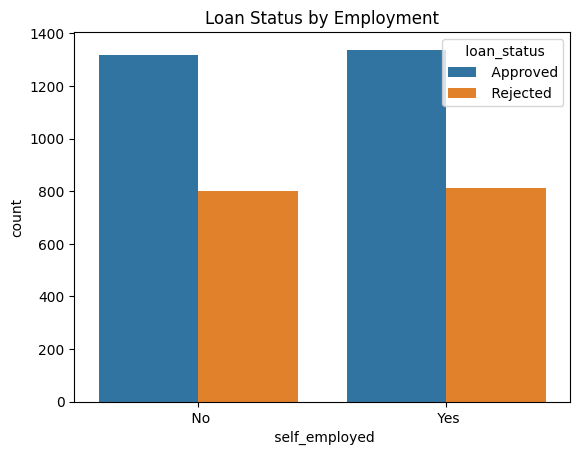

In [113]:
# Employment vs Loan-Status
sns.countplot(data=data, x=' self_employed', hue=' loan_status')
plt.title('Loan Status by Employment')
plt.show()

Identical approval and rejection counts for both groups

=> No difference in approval rates based on employment type

### Numeric Features Analysis

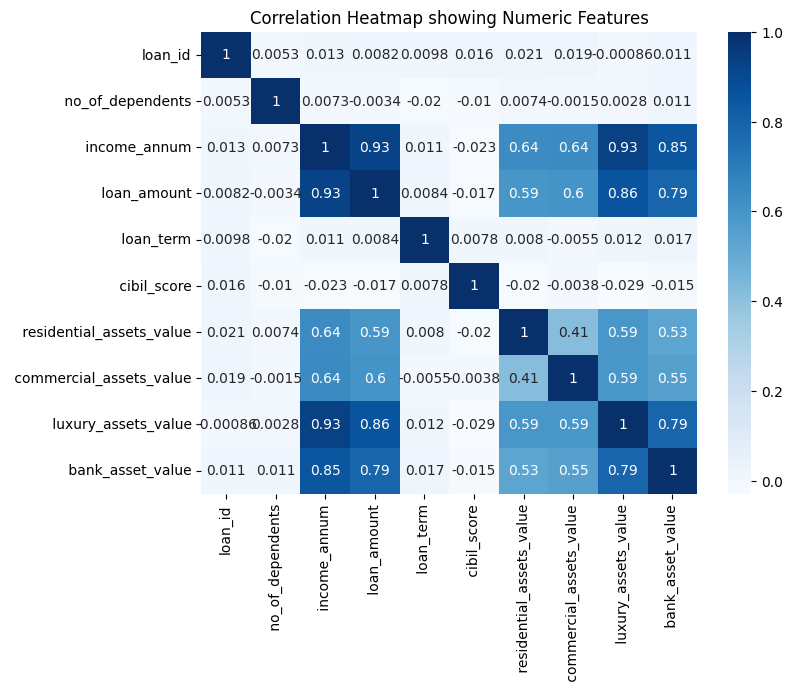

In [114]:
#Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data.select_dtypes(include='int64').corr(), cmap='Blues', annot=True)
plt.title("Correlation Heatmap showing Numeric Features")
plt.show()

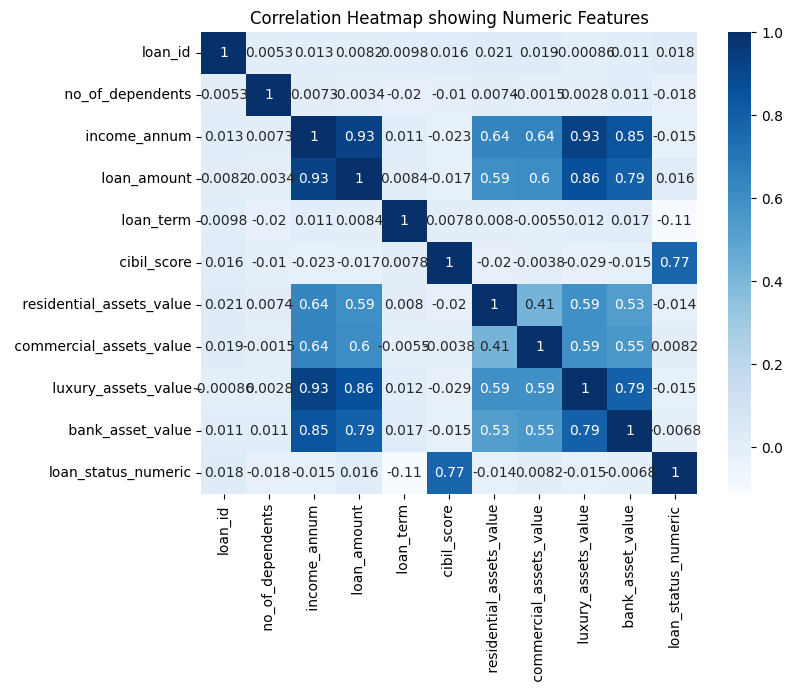

In [115]:
# Create a copy of the data to avoid modifying the original
data_numeric = data.copy()

# Convert loan_status to numeric (1 for Approved, 0 for Rejected)
data_numeric['loan_status_numeric'] = data[' loan_status'].apply(lambda x: 1 if x == ' Approved' else 0)

# Calculate correlation matrix for numeric columns plus our new loan_status_numeric
plt.figure(figsize=(8, 6))
sns.heatmap(data_numeric.select_dtypes(include='int64').corr(), cmap='Blues', annot=True)
plt.title("Correlation Heatmap showing Numeric Features")
plt.show()

High correlation between income, loan amount, and luxury assets suggests potential redundancy in features

The cibil_score is the most influential factor, highlighting the importance of credit history.

Higher income and assets improve approval chances, indicating that financial stability is crucial.

Larger loans and longer terms are viewed as riskier, leading to lower approval rates.



### Check Missing Values

In [116]:
#verify null values :null values cause errors in the model
data.isna().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

Our dataframe contains zero null values

In [117]:
#verify duplicates :duplicates cause overfitting    
data.duplicated().sum()


np.int64(0)

## Data Preprocessing

### Drop Unnecessary Columns

In [118]:
# loan_id is just inentifier: remore it
df = data.drop(columns=['loan_id'])

### Encode Categorical Features

In [119]:
# Apply One-hot Encoding for education and self_employed
df = pd.get_dummies(df, columns=[' education', ' self_employed'], drop_first=True)

# Encode Target Variable
df[' loan_status'] = df[' loan_status'].map({' Approved': 1, ' Rejected': 0})

### Feature Scaling

In [120]:
scaler = StandardScaler()
scaled_cols = [
    ' income_annum', ' loan_amount',
    ' loan_term', ' cibil_score', 
    ' residential_assets_value',
    ' commercial_assets_value', 
    ' luxury_assets_value',
    ' bank_asset_value'
]
df[scaled_cols] = scaler.fit_transform(df[scaled_cols])

In [121]:
#verify changes
df.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_ Not Graduate,self_employed_ Yes
0,2,1.617979,1.633052,0.192617,1.032792,-0.780058,2.877289,0.832028,0.930304,1,False,False
1,0,-0.341750,-0.324414,-0.508091,-1.061051,-0.733924,-0.631921,-0.694993,-0.515936,0,True,True
2,3,1.439822,1.610933,1.594031,-0.544840,-0.057300,-0.107818,1.996520,2.407316,0,False,False
3,3,1.119139,1.721525,-0.508091,-0.771045,1.649637,-0.381263,0.897943,0.899533,0,False,False
4,5,1.689242,1.002681,1.594031,-1.264055,0.757724,0.735304,1.568075,0.007172,0,True,True


### Feature Selection

## Modeling

### Train-Test Split

In [122]:
# Features
X = df.drop(' loan_status', axis=1)

# Target
y = df[' loan_status']

In [123]:
# Split into training and Testing set (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [124]:
print('Training Set Size', X_train.shape)
print('Testing Set Size', X_test.shape)

Training Set Size (3415, 11)
Testing Set Size (854, 11)


### Handle Imbalance Data

In [125]:
# Check Class Imbalance
# Class Distribution in Training Set
print('Class Distribution (counts): ')
print(y_train.value_counts())

print('\nClass Distribution (percentage):')
print(y_train.value_counts(normalize=True)*100)

Class Distribution (counts): 
 loan_status
1    2125
0    1290
Name: count, dtype: int64

Class Distribution (percentage):
 loan_status
1    62.225476
0    37.774524
Name: proportion, dtype: float64


In [126]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [127]:
# Apply Smote (Oversampling)
# Initialize SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [128]:
print("Before SMOTE: ", y_train.value_counts())
print("\nAfter SMOTE: ", y_train_res.value_counts())

Before SMOTE:   loan_status
1    2125
0    1290
Name: count, dtype: int64

After SMOTE:   loan_status
1    2125
0    2125
Name: count, dtype: int64


### Model Training

our problem is classifications so we need to choose 

#### 1.Decision Tree

In [129]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier()
param_grid = {'max_depth': [2,3, 4,5,6,7,8,9,10,11,13,15,20]}

grid_search = GridSearchCV(dt_clf, param_grid, scoring = 'recall_weighted',cv=kFold, return_train_score=True)
grid_search.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;

In [130]:
grid_search.best_params_

{'max_depth': 15}

In [131]:
dt_clf = DecisionTreeClassifier(max_depth=2)
dt_clf.fit(X_train, y_train)
y_pred_train = dt_clf.predict(X_train)
y_pred_test = dt_clf.predict(X_test)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

In [132]:
print("Confusion Matrix \n",confusion_matrix(y_test,y_pred_test))
print("\n")
print("<-------------------Classification Report---------------------->\n")
print(classification_report(y_test,y_pred_test))
print("\n")
print("<---------------Accuracy Scores------------------->\n")
print('Train Accuracy score: ',train_accuracy)
print('Test Accuracy score:',test_accuracy)

Confusion Matrix 
 [[293  30]
 [  0 531]]


<-------------------Classification Report---------------------->

              precision    recall  f1-score   support

           0       1.00      0.91      0.95       323
           1       0.95      1.00      0.97       531

    accuracy                           0.96       854
   macro avg       0.97      0.95      0.96       854
weighted avg       0.97      0.96      0.96       854



<---------------Accuracy Scores------------------->

Train Accuracy score:  0.9557833089311859
Test Accuracy score: 0.9648711943793911


#### 2.Random Forest Classifier

In [133]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=600)
rf_clf.fit(X_train, y_train)
y_pred_train = rf_clf.predict(X_train)
y_pred_test = rf_clf.predict(X_test)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

In [134]:
print("Confusion Matrix \n",confusion_matrix(y_test,y_pred_test))
print("\n")
print("<-------------------Classification Report---------------------->\n")
print(classification_report(y_test,y_pred_test))
print("\n")
print("<---------------Accuracy Scores------------------->\n")
#print('Train Accuracy score: ',train_accuracy)
print('Test Accuracy score:',test_accuracy)

Confusion Matrix 
 [[314   9]
 [  5 526]]


<-------------------Classification Report---------------------->

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



<---------------Accuracy Scores------------------->

Test Accuracy score: 0.9836065573770492


#### 3.Gradient Boosting

In [135]:
from sklearn.ensemble import GradientBoostingClassifier
gb_clf = GradientBoostingClassifier(learning_rate = 0.05)
gb_clf.fit(X_train, y_train)
#print('Train score: {0:0.2f}'.format(gb_clf.score(X_train, y_train)))
#print('Test score: {0:0.2f}'.format(gb_clf.score(X_test, y_test)))
y_pred_train = gb_clf.predict(X_train)
y_pred_test = gb_clf.predict(X_test)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

In [136]:
from sklearn.ensemble import GradientBoostingClassifier
gb_clf = GradientBoostingClassifier(learning_rate = 0.05)
gb_clf.fit(X_train, y_train)
#print('Train score: {0:0.2f}'.format(gb_clf.score(X_train, y_train)))
#print('Test score: {0:0.2f}'.format(gb_clf.score(X_test, y_test)))
y_pred_train = gb_clf.predict(X_train)
y_pred_test = gb_clf.predict(X_test)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

### Model Evaluation:Model Comparision

In [137]:
# Create Evaluation Function 
def evaluate_model(model, X_test, y_test, model_name="Model"):
    # Predictions
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return {"model": model_name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

In [138]:
#Evaluate all # Models
results = []

results.append(evaluate_model(gb_clf, X_test, y_test, "Gradient Boosting Classifier"))
results.append(evaluate_model(dt_clf, X_test, y_test, "Decision Tree"))
results.append(evaluate_model(rf_clf, X_test, y_test, "Random Forest"))

NameError: name 'f1_score' is not defined

In [ ]:
# Compare Result 
results_df = pd.DataFrame(results)
print("\nModel Comparison:\n")
print(results_df.sort_values(by="f1", ascending=False))

## Save the Models

In [ ]:
import joblib 

# Save the StandardScaler
joblib.dump(scaler, "Models/scaler.pkl")

# Save the SMOTE
joblib.dump(smote, "Models/smote.pkl")

# Logistic Regression
joblib.dump(lr_clf, "Models/Gradient_Boosting_Classifier_model.pkl")

# Decision Tree
joblib.dump(dt_clf, "Models/decision_tree_model.pkl")

# Random Forest
joblib.dump(rf_clf, "Models/random_forest_model.pkl")

print("Model Saved Successfully!")